# PML Course Project

Import the audio-processing, machine-learning, deep-learning, and visualization libraries used in this experiment. Fix the random seed, configure the preprocessing, training, and OOD-inference switches, locate the project root, prepare output directories, and apply a consistent plotting style.


In [1]:
from __future__ import annotations

import csv, io, json, math, os, random, zipfile, warnings
from dataclasses import dataclass
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Audio, display
from matplotlib import font_manager
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_recall_curve, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset

SEED = 2026
RUN_FULL_PREPROCESS = False
RUN_TRAINING = False
RUN_OOD_INFERENCE = False
REBUILD_ALL_FIGURES = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_root() -> Path:
    override = os.getenv("MOSQUITO_PROJECT_ROOT")
    candidates = [Path(override)] if override else []
    candidates += [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if candidate and (candidate / "scripts").is_dir() and (candidate / "outputs").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Project root not found. Set MOSQUITO_PROJECT_ROOT and restart the kernel."
    )

ROOT = find_project_root()
FIG_DIR = ROOT / "outputs" / "notebook_figures"
TABLE_DIR = ROOT / "outputs" / "notebook_tables"
BUNDLE_ZIP = ROOT / "output" / "jupyter-notebook" / "submission_data.zip"
RUNTIME_DIR = ROOT / "outputs" / "notebook_runtime_data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def ensure_bundle_fallback():
    # Extract the small reproducibility bundle only when repository data are absent.
    if not BUNDLE_ZIP.exists():
        return
    local_fast_files = [
        ROOT / "data/processed/humbugdb_mfcc/labels.npy",
        ROOT / "outputs/logistic_mil_gpu/fold_1.pt",
        ROOT / "outputs/ood_evaluation_balanced/probabilities.npz",
    ]
    if all(path.exists() for path in local_fast_files):
        return
    with zipfile.ZipFile(BUNDLE_ZIP) as bundle:
        for member in bundle.infolist():
            prefix = "submission_data/"
            if member.is_dir() or not member.filename.startswith(prefix):
                continue
            destination = RUNTIME_DIR / member.filename[len(prefix):]
            if not destination.exists():
                destination.parent.mkdir(parents=True, exist_ok=True)
                destination.write_bytes(bundle.read(member))
    print("Fast-reproduction files were restored from submission_data.zip.")

ensure_bundle_fallback()

COLORS = {
    "ink": "#201547", "purple": "#56329a", "lavender": "#9f8bd7",
    "cyan": "#38a8c7", "orange": "#ef8a45", "green": "#4f9d69",
    "red": "#cc4b55", "paper": "#fbfaff", "grid": "#ded8ec",
}
for candidate in [Path("C:/Windows/Fonts/msyh.ttc"), Path("C:/Windows/Fonts/simhei.ttf")]:
    if candidate.exists():
        font_manager.fontManager.addfont(candidate)
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=candidate).get_name()
        break
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 180, "axes.titlesize": 13,
    "axes.labelsize": 10, "axes.edgecolor": COLORS["ink"],
    "text.color": COLORS["ink"], "axes.labelcolor": COLORS["ink"],
    "xtick.color": COLORS["ink"], "ytick.color": COLORS["ink"],
})

def save_figure(fig, filename: str):
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    return path.relative_to(ROOT)

print("The project root was detected automatically; MOSQUITO_PROJECT_ROOT can override it.")
print(f"Figure directory: {FIG_DIR.relative_to(ROOT)}")
print(f"Mode: preprocess={RUN_FULL_PREPROCESS}, training={RUN_TRAINING}, OOD inference={RUN_OOD_INFERENCE}")


The project root was detected automatically; MOSQUITO_PROJECT_ROOT can override it.
Figure directory: outputs\notebook_figures
Mode: preprocess=False, training=False, OOD inference=False


## 1. File Paths and Runtime Checks

Define candidate paths for local files and the reproducibility bundle, verify that labels, groups, checkpoints, and frozen predictions are available, and report a clear error when a required file is missing.


In [2]:
def prefer(local: Path, fallback: Path) -> Path:
    return local if local.exists() else fallback

PATHS = {
    "metadata": prefer(ROOT / "data/processed/humbugdb_mfcc/metadata.json", RUNTIME_DIR / "dataset/metadata.json"),
    "features": ROOT / "data/processed/humbugdb_mfcc/mfcc_features.npy",
    "labels": prefer(ROOT / "data/processed/humbugdb_mfcc/labels.npy", RUNTIME_DIR / "dataset/labels.npy"),
    "groups": prefer(ROOT / "data/processed/humbugdb_mfcc/groups.npy", RUNTIME_DIR / "dataset/groups.npy"),
    "sample_ids": prefer(ROOT / "data/processed/humbugdb_mfcc/sample_ids.npy", RUNTIME_DIR / "dataset/sample_ids.npy"),
    "label_csv": ROOT / "data/raw/humbugdb/neurips_2021_zenodo_0_0_1.csv",
    "logistic_metrics": prefer(ROOT / "outputs/logistic_mil_gpu/metrics.json", RUNTIME_DIR / "logistic_mil/metrics.json"),
    "ood_metrics": prefer(ROOT / "outputs/ood_evaluation_balanced/metrics.json", RUNTIME_DIR / "comparison/ood_balanced/metrics.json"),
    "ood_probabilities": prefer(ROOT / "outputs/ood_evaluation_balanced/probabilities.npz", RUNTIME_DIR / "comparison/ood_balanced/probabilities.npz"),
}
def logistic_file(name: str) -> Path:
    return prefer(ROOT / "outputs/logistic_mil_gpu" / name, RUNTIME_DIR / "logistic_mil" / name)

required_fast = [PATHS[key] for key in ["metadata", "labels", "groups", "sample_ids", "logistic_metrics", "ood_metrics", "ood_probabilities"]]
required_fast += [logistic_file(f"fold_{fold}.pt") for fold in range(1, 6)]
if not PATHS["features"].exists():
    required_fast += [RUNTIME_DIR / "examples/id_mosquito_mfcc.npy", RUNTIME_DIR / "examples/id_background_mfcc.npy"]
missing = [path for path in required_fast if not path.exists()]
if missing:
    lines = "\n".join(f"  - {path.relative_to(ROOT)}" for path in missing)
    raise FileNotFoundError(
        "Fast-reproduction files are incomplete:\n" + lines +
        "\nExtract submission_data.zip at the project root, or restore the repository outputs/ and data/processed/ directories."
    )
print(f"Fast-reproduction check passed: all {len(required_fast)} required files are available.")


Fast-reproduction check passed: all 12 required files are available.


## 2. Dataset Composition

Load the HumBugDB labels and OOD evaluation records, verify sample counts by class and source, save the dataset manifest, and plot the ID and OOD dataset composition.


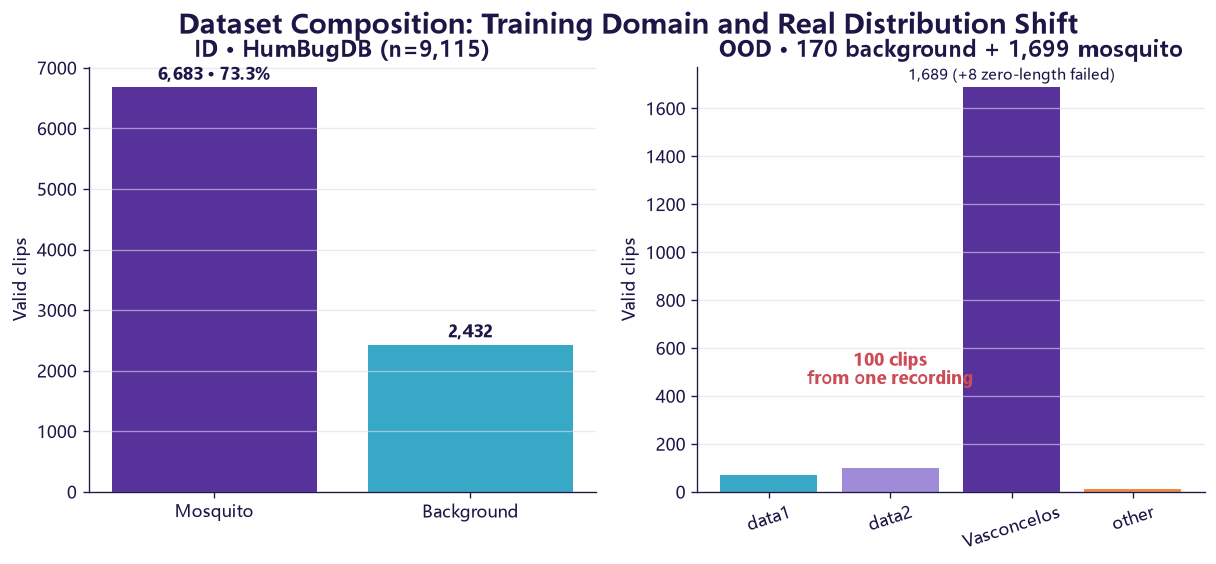

,split,source,label,count,note
0,ID,HumBugDB mosquito,1,6683,73.3% of valid ID clips
1,ID,HumBugDB background,0,2432,grouped by original recording
2,OOD,data1,0,70,independent background clips
3,OOD,data2,0,100,segments from one source recording
4,OOD,Vasconcelos,1,1689,8 zero-length files excluded
5,OOD,other,1,10,additional mosquito recordings


In [3]:
with PATHS["metadata"].open("r", encoding="utf-8") as f:
    data_meta = json.load(f)
labels = np.asarray(np.load(PATHS["labels"]), dtype=np.int64)
groups = np.asarray(np.load(PATHS["groups"], allow_pickle=True))
sample_ids = np.asarray(np.load(PATHS["sample_ids"], allow_pickle=True))
with PATHS["ood_metrics"].open("r", encoding="utf-8") as f:
    ood_report = json.load(f)

manifest_rows = [
    {"split": "ID", "source": "HumBugDB mosquito", "label": 1, "count": int(labels.sum()), "note": "73.3% of valid ID clips"},
    {"split": "ID", "source": "HumBugDB background", "label": 0, "count": int((labels == 0).sum()), "note": "grouped by original recording"},
    {"split": "OOD", "source": "data1", "label": 0, "count": 70, "note": "independent background clips"},
    {"split": "OOD", "source": "data2", "label": 0, "count": 100, "note": "segments from one source recording"},
    {"split": "OOD", "source": "Vasconcelos", "label": 1, "count": 1689, "note": "8 zero-length files excluded"},
    {"split": "OOD", "source": "other", "label": 1, "count": 10, "note": "additional mosquito recordings"},
]
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(TABLE_DIR / "table_02_dataset_manifest.csv", index=False, encoding="utf-8-sig")

assert len(labels) == 9115 and int(labels.sum()) == 6683 and int((labels == 0).sum()) == 2432
assert ood_report["dataset"]["loaded_valid_class_counts_before_selection"] == {"0": 170, "1": 1699}
assert ood_report["dataset"]["failed_sample_count"] == 8

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].bar(["Mosquito", "Background"], [6683, 2432], color=[COLORS["purple"], COLORS["cyan"]])
axes[0].set_title("ID · HumBugDB (n=9,115)", fontweight="bold")
axes[0].set_ylabel("Valid clips")
axes[0].text(0, 6683 + 120, "6,683 · 73.3%", ha="center", fontweight="bold")
axes[0].text(1, 2432 + 120, "2,432", ha="center", fontweight="bold")
ood_names = ["data1", "data2", "Vasconcelos", "other"]
ood_counts = [70, 100, 1689, 10]
axes[1].bar(ood_names, ood_counts, color=[COLORS["cyan"], COLORS["lavender"], COLORS["purple"], COLORS["orange"]])
axes[1].set_title("OOD · 170 background + 1,699 mosquito", fontweight="bold")
axes[1].set_ylabel("Valid clips")
axes[1].tick_params(axis="x", rotation=18)
axes[1].text(1, 450, "100 clips\nfrom one recording", ha="center", color=COLORS["red"], fontweight="bold")
axes[1].text(2, 1720, "1,689 (+8 zero-length failed)", ha="center", fontsize=9)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=COLORS["grid"], alpha=.6)
fig.suptitle("Dataset Composition: Training Domain and Real Distribution Shift", fontsize=16, fontweight="bold")
save_figure(fig, "fig_02_dataset_composition.png")
manifest_df


### 2.1 Audio Loading and MFCC Examples

Implement 8 kHz resampling and 39-channel MFCC/Delta/Delta-squared extraction. Load mosquito and background audio from ID and OOD data, plot the waveform and MFCC for all four categories, and provide audio players.


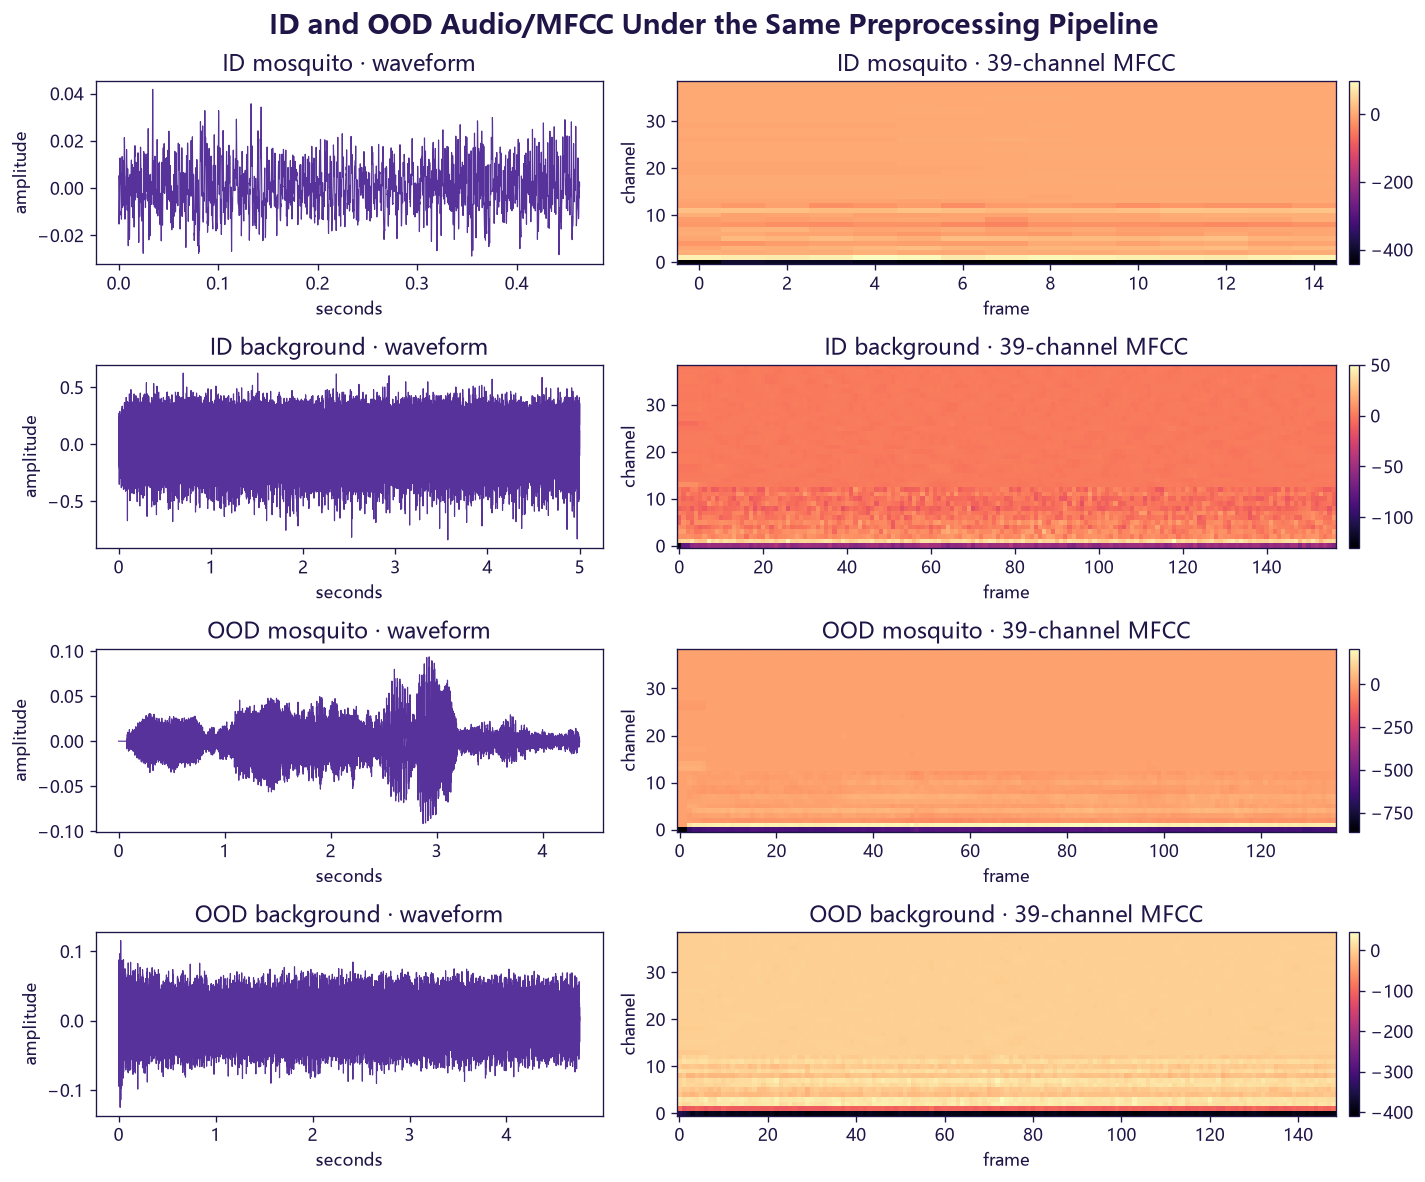

Audio players (up to 5 seconds per clip):
ID mosquito: 53.wav


ID background: 222691.wav


OOD mosquito: m1.wav


OOD background: y01.wav


In [4]:
def extract_mfcc39(y: np.ndarray, sr: int = 8000) -> np.ndarray:
    # Shared 39-channel representation for training and OOD: 13 MFCC + Delta + Delta-squared.
    if sr != 8000:
        y = librosa.resample(y.astype(np.float32), orig_sr=sr, target_sr=8000)
        sr = 8000
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=512, hop_length=256)
    if mfcc.shape[1] >= 9:
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
    else:
        delta = np.zeros_like(mfcc)
        delta2 = np.zeros_like(mfcc)
    return np.concatenate([mfcc, delta, delta2], axis=0).astype(np.float32)

def read_wav_from_zip(zip_path: Path, member_predicate, max_seconds: float | None = None):
    with zipfile.ZipFile(zip_path) as zf:
        member = next(name for name in zf.namelist() if member_predicate(Path(name)))
        raw = zf.read(member)
    y, sr = sf.read(io.BytesIO(raw), dtype="float32", always_2d=False)
    if y.ndim == 2:
        y = y.mean(axis=1)
    if max_seconds is not None:
        y = y[: int(sr * max_seconds)]
    if sr != 8000:
        y = librosa.resample(y, orig_sr=sr, target_sr=8000)
        sr = 8000
    return y.astype(np.float32), sr, member

def find_humbug_audio(record_id: str, max_seconds: float = 5.0):
    for archive in sorted((ROOT / "data/raw/humbugdb").glob("humbugdb_neurips_2021_*.zip")):
        try:
            return read_wav_from_zip(archive, lambda p: p.stem == record_id, max_seconds)
        except StopIteration:
            continue
    raise FileNotFoundError(f"HumBugDB record {record_id}.wav not found")

def read_example_wav(name: str):
    path = RUNTIME_DIR / "examples" / f"{name}.wav"
    y, sr = sf.read(path, dtype="float32", always_2d=False)
    return y, sr, path.name

id_positive_id = str(sample_ids[np.flatnonzero(labels == 1)[0]])
id_negative_id = str(sample_ids[np.flatnonzero(labels == 0)[0]])
has_humbug_raw = any((ROOT / "data/raw/humbugdb").glob("humbugdb_neurips_2021_*.zip"))
id_pos = find_humbug_audio(id_positive_id) if has_humbug_raw else read_example_wav("id_mosquito")
id_neg = find_humbug_audio(id_negative_id) if has_humbug_raw else read_example_wav("id_background")
ood_pos_path = prefer(ROOT / "data/raw/ood_positive/other.zip", RUNTIME_DIR / "ood/other.zip")
ood_neg_path = prefer(ROOT / "data/raw/ood_negative/data1.zip", RUNTIME_DIR / "ood/data1.zip")
ood_pos = read_wav_from_zip(ood_pos_path, lambda p: p.suffix.lower() == ".wav", 5.0)
ood_neg = read_wav_from_zip(ood_neg_path, lambda p: p.suffix.lower() == ".wav", 5.0)
audio_examples = {
    "ID mosquito": id_pos, "ID background": id_neg,
    "OOD mosquito": ood_pos, "OOD background": ood_neg,
}

fig, axes = plt.subplots(4, 2, figsize=(12, 10), gridspec_kw={"width_ratios": [1, 1.35]})
for row, (name, (y, sr, member)) in enumerate(audio_examples.items()):
    t = np.arange(len(y)) / sr
    axes[row, 0].plot(t, y, color=COLORS["purple"], linewidth=.7)
    axes[row, 0].set(title=f"{name} · waveform", xlabel="seconds", ylabel="amplitude")
    mfcc39 = extract_mfcc39(y, sr)
    image = axes[row, 1].imshow(mfcc39, aspect="auto", origin="lower", cmap="magma")
    axes[row, 1].set(title=f"{name} · 39-channel MFCC", xlabel="frame", ylabel="channel")
    fig.colorbar(image, ax=axes[row, 1], fraction=.018, pad=.02)
fig.suptitle("ID and OOD Audio/MFCC Under the Same Preprocessing Pipeline", fontsize=16, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig_02_mfcc_examples.png")

print("Audio players (up to 5 seconds per clip):")
for name, (y, sr, member) in audio_examples.items():
    print(f"{name}: {member}")
    display(Audio(y, rate=sr))


### 2.2 Full Preprocessing Entry Point

Define the command that generates MFCC features from the four raw HumBugDB ZIP archives. Full preprocessing runs only when `RUN_FULL_PREPROCESS=True`; otherwise, existing feature files are reused.


In [5]:
def run_full_humbug_preprocess():
    import subprocess, sys
    raw_dir = ROOT / "data/raw/humbugdb"
    expected = [raw_dir / f"humbugdb_neurips_2021_{i}.zip" for i in range(1, 5)]
    expected.append(raw_dir / "neurips_2021_zenodo_0_0_1.csv")
    missing = [p for p in expected if not p.exists()]
    if missing:
        raise FileNotFoundError("Required official HumBugDB files are missing:\n" + "\n".join(map(str, missing)))
    command = [
        sys.executable, str(ROOT / "scripts/process_humbugdb_from_zip.py"),
        "--zip-dir", str(raw_dir), "--csv", str(expected[-1]),
        "--output", str(ROOT / "data/processed/humbugdb_mfcc"),
        "--n-mfcc", "13", "--sample-rate", "8000", "--hop-length", "256",
        "--n-fft", "512", "--window-size", "64", "--min-duration", "0.1",
        "--max-duration", "60.0",
    ]
    subprocess.run(command, check=True, cwd=ROOT)

if RUN_FULL_PREPROCESS:
    run_full_humbug_preprocess()
else:
    print("RUN_FULL_PREPROCESS=False: using the existing 9,115 MFCC feature records.")


RUN_FULL_PREPROCESS=False: using the existing 9,115 MFCC feature records.


## 3. Short-Clip Padding and Long-Clip Windowing

Implement trailing-zero trimming, short-clip padding, sliding windows for long clips, and 78-dimensional window statistics. Use real samples to illustrate three random padding positions and 50% overlapping windows.


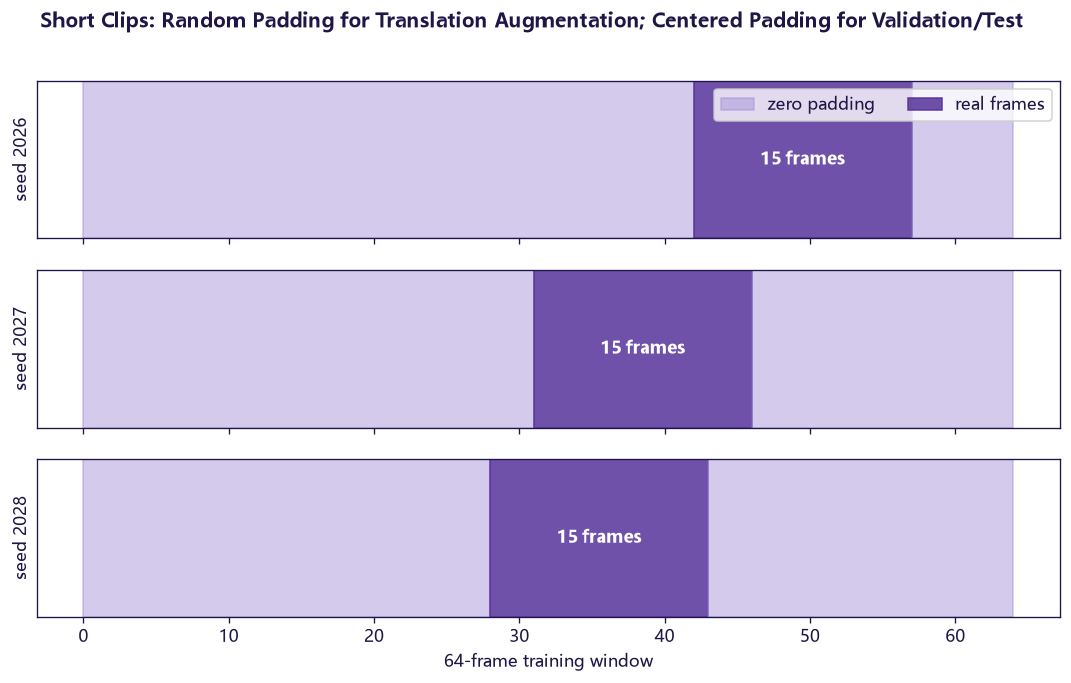

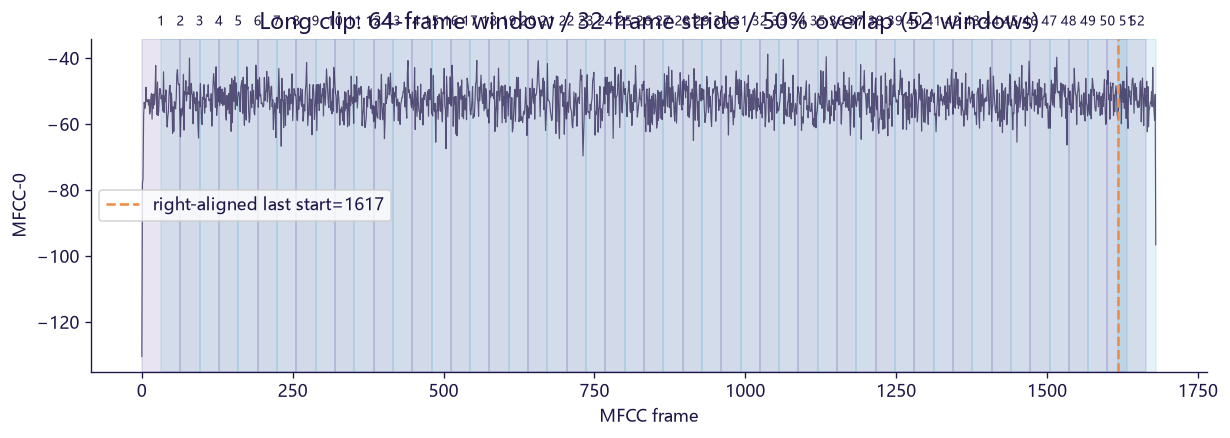

WindowsPath('outputs/notebook_figures/fig_03_long_windowing.png')

In [6]:
WINDOW_SIZE, HOP_SIZE, TOP_K = 64, 32, 3

def trim_existing_zero_padding(mfcc: np.ndarray, tolerance: float = 1e-12) -> np.ndarray:
    nonzero = np.flatnonzero(np.any(np.abs(mfcc) > tolerance, axis=0))
    return mfcc[:, :1] if len(nonzero) == 0 else mfcc[:, : int(nonzero[-1]) + 1]

def window_starts(frame_count: int, window_size: int = 64, hop_size: int = 32):
    if frame_count <= window_size:
        return [0]
    last = frame_count - window_size
    starts = list(range(0, last + 1, hop_size))
    if starts[-1] != last:
        starts.append(last)
    return starts

def pad_or_window_mfcc(mfcc, random_short_padding=False, rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    channels, frames = mfcc.shape
    if frames < WINDOW_SIZE:
        missing = WINDOW_SIZE - frames
        left = int(rng.integers(0, missing + 1)) if random_short_padding else missing // 2
        padded = np.pad(mfcc, ((0, 0), (left, missing - left)))
        return padded[None], [0], (left, missing - left)
    starts = window_starts(frames, WINDOW_SIZE, HOP_SIZE)
    return np.stack([mfcc[:, s:s + WINDOW_SIZE] for s in starts]), starts, (0, 0)

def make_window_features(mfcc, random_short_padding=False, rng=None):
    windows, starts, padding = pad_or_window_mfcc(mfcc, random_short_padding, rng)
    features = np.concatenate([windows.mean(axis=2), windows.std(axis=2)], axis=1)
    return features.astype(np.float32), windows, starts, padding

if PATHS["features"].exists():
    mfcc_all = np.load(PATHS["features"], allow_pickle=True)
else:
    mfcc_all = np.empty(2, dtype=object)
    mfcc_all[0] = np.load(RUNTIME_DIR / "examples/id_mosquito_mfcc.npy")
    mfcc_all[1] = np.load(RUNTIME_DIR / "examples/id_background_mfcc.npy")
actual_lengths = np.array([trim_existing_zero_padding(np.asarray(x)).shape[1] for x in mfcc_all])
short_index = int(np.flatnonzero(actual_lengths < WINDOW_SIZE)[0])
long_index = int(np.flatnonzero(actual_lengths > 220)[0])
short_mfcc = trim_existing_zero_padding(np.asarray(mfcc_all[short_index], dtype=np.float32))
long_mfcc = trim_existing_zero_padding(np.asarray(mfcc_all[long_index], dtype=np.float32))

fig, axes = plt.subplots(3, 1, figsize=(11, 5.8), sharex=True)
for ax, seed in zip(axes, [2026, 2027, 2028]):
    _, _, _, (left, right) = make_window_features(short_mfcc, True, np.random.default_rng(seed))
    ax.axvspan(0, left, color=COLORS["lavender"], alpha=.45, label="zero padding")
    ax.axvspan(left, left + short_mfcc.shape[1], color=COLORS["purple"], alpha=.85, label="real frames")
    ax.axvspan(left + short_mfcc.shape[1], WINDOW_SIZE, color=COLORS["lavender"], alpha=.45)
    ax.set_yticks([]); ax.set_ylabel(f"seed {seed}")
    ax.text(left + short_mfcc.shape[1] / 2, .5, f"{short_mfcc.shape[1]} frames", ha="center", va="center", color="white", fontweight="bold")
axes[-1].set_xlabel("64-frame training window")
axes[0].legend(ncol=2, loc="upper right")
fig.suptitle("Short Clips: Random Padding for Translation Augmentation; Centered Padding for Validation/Test", fontweight="bold")
save_figure(fig, "fig_03_short_padding.png")

starts = window_starts(long_mfcc.shape[1])
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(np.arange(long_mfcc.shape[1]), long_mfcc[0], color=COLORS["ink"], linewidth=.7, alpha=.7)
for i, start in enumerate(starts):
    ax.axvspan(start, start + WINDOW_SIZE, color=COLORS["purple"] if i % 2 == 0 else COLORS["cyan"], alpha=.13)
    ax.text(start + WINDOW_SIZE/2, ax.get_ylim()[1] * .88, str(i + 1), ha="center", fontsize=8)
ax.axvline(starts[-1], color=COLORS["orange"], linestyle="--", label=f"right-aligned last start={starts[-1]}")
ax.set(xlabel="MFCC frame", ylabel="MFCC-0", title=f"Long clip: 64-frame window / 32-frame stride / 50% overlap ({len(starts)} windows)")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "fig_03_long_windowing.png")


### 3.1 Five-Fold Window Probabilities and Top-3 Mean

Load the five Logistic MIL fold checkpoints, compute and average window probabilities for a real long clip, highlight the three highest-probability windows, and use their mean as the clip-level probability.


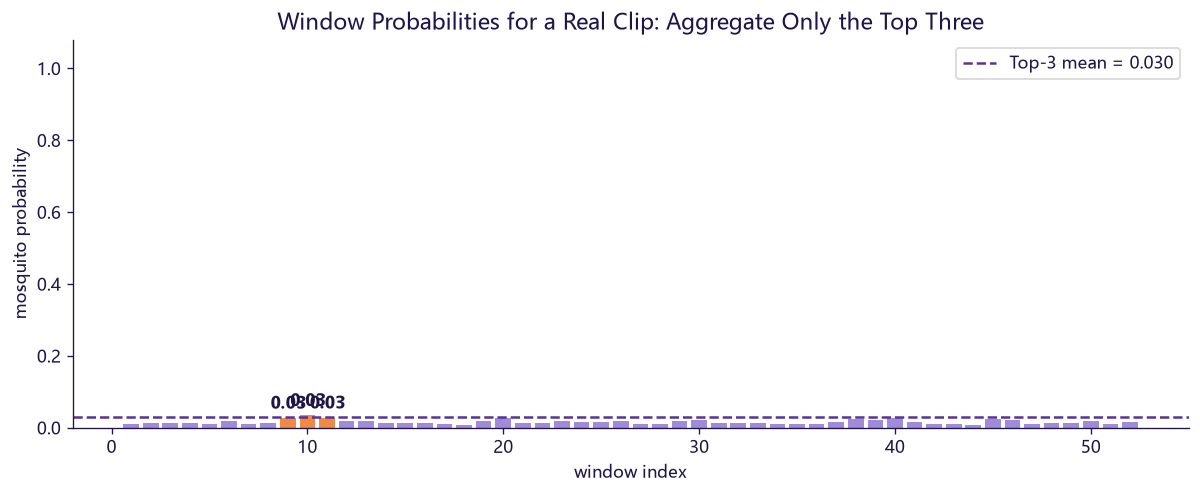

Clip probability = mean(top 3) = 0.0303


In [7]:
class WindowLogisticRegression(nn.Module):
    def __init__(self, input_dim: int = 78):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(-1)

@torch.no_grad()
def ensemble_window_probabilities(mfcc: np.ndarray):
    raw_features, _, starts, _ = make_window_features(mfcc, False, np.random.default_rng(SEED))
    fold_probabilities = []
    for fold in range(1, 6):
        checkpoint = torch.load(logistic_file(f"fold_{fold}.pt"), map_location="cpu", weights_only=False)
        model = WindowLogisticRegression(checkpoint["input_dim"])
        model.load_state_dict(checkpoint["model_state_dict"]); model.eval()
        scaled = (raw_features - checkpoint["standardizer_mean"]) / checkpoint["standardizer_scale"]
        fold_probabilities.append(torch.sigmoid(model(torch.from_numpy(scaled).float())).numpy())
    return np.mean(fold_probabilities, axis=0), starts

window_probabilities, starts = ensemble_window_probabilities(long_mfcc)
top_indices = np.argsort(window_probabilities)[-TOP_K:]
clip_probability = float(window_probabilities[top_indices].mean())
colors = [COLORS["orange"] if i in top_indices else COLORS["lavender"] for i in range(len(starts))]
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(np.arange(1, len(starts) + 1), window_probabilities, color=colors)
ax.axhline(clip_probability, color=COLORS["purple"], linestyle="--", label=f"Top-3 mean = {clip_probability:.3f}")
for i in top_indices:
    ax.text(i + 1, window_probabilities[i] + .025, f"{window_probabilities[i]:.2f}", ha="center", fontweight="bold")
ax.set(xlabel="window index", ylabel="mosquito probability", ylim=(0, 1.08), title="Window Probabilities for a Real Clip: Aggregate Only the Top Three")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "fig_03_top3_pooling.png")
print(f"Clip probability = mean(top 3) = {clip_probability:.4f}")


# Other Models

This section retains model definitions, the experimental path, and reevaluation from frozen predictions. **These candidate models are not retrained**, so the notebook's training resources remain focused on the final Logistic MIL model.


## 4.1 Baseline and Windowed SVM Variants

Summarize the inputs, feature dimensions, aggregation methods, and main observations for SVM Baseline, SVM Pro, SVM Pro2, and SVM Large. Generate a method-evolution table and flowchart. Numerical SVM metrics are not reported because frozen predictions under the shared protocol are unavailable.


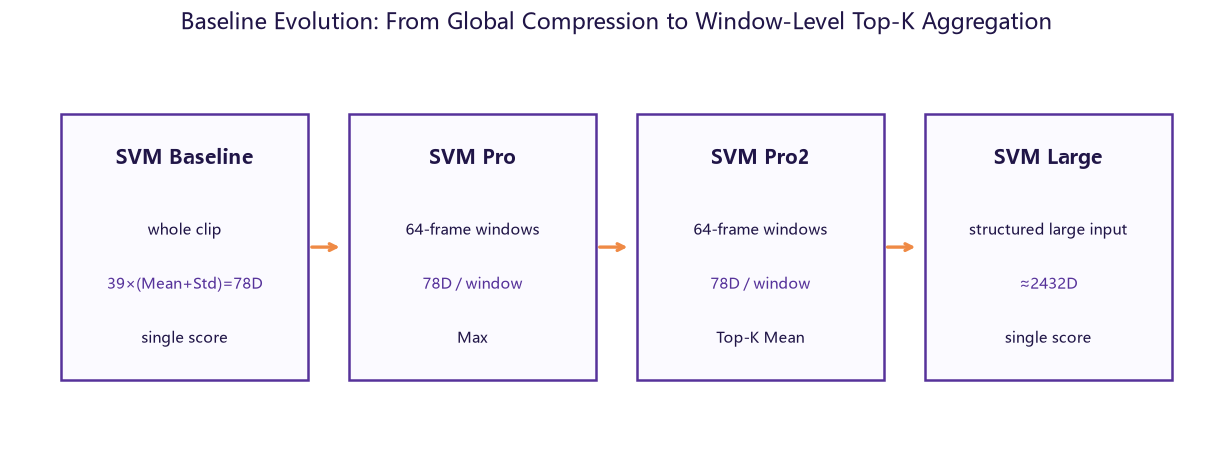

,model,input,dimension,pooling,observation
0,SVM Baseline,whole clip,39×(Mean+Std)=78D,single score,temporal structure is fully flattened
1,SVM Pro,64-frame windows,78D / window,Max,sensitive to a single anomalous high score
2,SVM Pro2,64-frame windows,78D / window,Top-K Mean,more robust aggregation; foundation of final m...
3,SVM Large,structured large input,≈2432D,single score,"higher dimension, cost, and overfitting risk"


In [8]:
baseline_rows = [
    ["SVM Baseline", "whole clip", "39×(Mean+Std)=78D", "single score", "temporal structure is fully flattened"],
    ["SVM Pro", "64-frame windows", "78D / window", "Max", "sensitive to a single anomalous high score"],
    ["SVM Pro2", "64-frame windows", "78D / window", "Top-K Mean", "more robust aggregation; foundation of final method"],
    ["SVM Large", "structured large input", "≈2432D", "single score", "higher dimension, cost, and overfitting risk"],
]
baseline_df = pd.DataFrame(baseline_rows, columns=["model", "input", "dimension", "pooling", "observation"])
baseline_df.to_csv(TABLE_DIR / "table_04_baseline_evolution.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(13, 4.5)); ax.axis("off")
x = np.arange(4)
for i, row in baseline_df.iterrows():
    ax.add_patch(plt.Rectangle((i-.43, .18), .86, .64, facecolor=COLORS["paper"], edgecolor=COLORS["purple"], linewidth=1.5))
    ax.text(i, .70, row.model, ha="center", fontweight="bold", fontsize=12)
    ax.text(i, .53, row.input, ha="center", fontsize=9)
    ax.text(i, .40, row.dimension, ha="center", fontsize=9, color=COLORS["purple"])
    ax.text(i, .27, row.pooling, ha="center", fontsize=9)
    if i < 3:
        ax.annotate("", xy=(i+.55, .5), xytext=(i+.43, .5), arrowprops=dict(arrowstyle="->", color=COLORS["orange"], lw=2))
ax.set(xlim=(-.6, 3.6), ylim=(0, 1), title="Baseline Evolution: From Global Compression to Window-Level Top-K Aggregation")
save_figure(fig, "fig_04_baseline_evolution.png")
baseline_df


## 4.2 Candidate Model Structures and Evaluation Protocol

Define the candidate MLP architectures, summarize each model's input, architecture, aggregation method, and split protocol, and generate a model matrix plus a leakage-prevention evaluation flowchart.


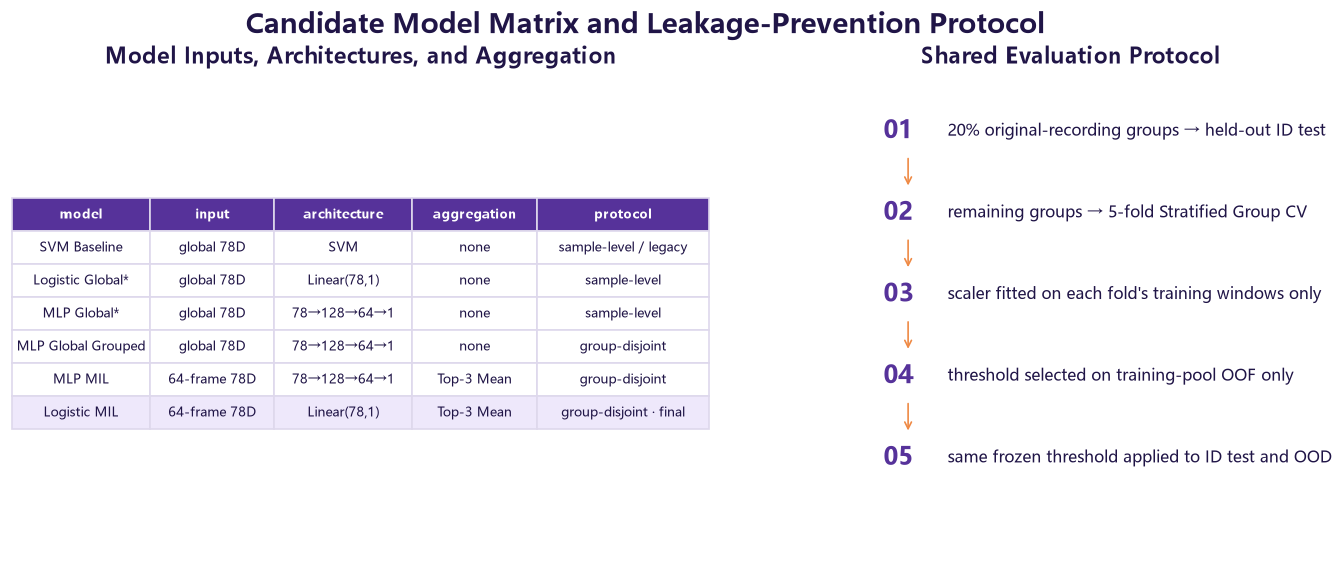

,model,input,architecture,aggregation,protocol
0,SVM Baseline,global 78D,SVM,none,sample-level / legacy
1,Logistic Global*,global 78D,"Linear(78,1)",none,sample-level
2,MLP Global*,global 78D,78→128→64→1,none,sample-level
3,MLP Global Grouped,global 78D,78→128→64→1,none,group-disjoint
4,MLP MIL,64-frame 78D,78→128→64→1,Top-3 Mean,group-disjoint
5,Logistic MIL,64-frame 78D,"Linear(78,1)",Top-3 Mean,group-disjoint · final


In [9]:
class GlobalMLP(nn.Module):
    def __init__(self, input_dim=78, hidden1=128, hidden2=64, dropout=.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.LayerNorm(hidden1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2), nn.LayerNorm(hidden2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x): return self.network(x).squeeze(-1)

model_rows = [
    ["SVM Baseline", "global 78D", "SVM", "none", "sample-level / legacy"],
    ["Logistic Global*", "global 78D", "Linear(78,1)", "none", "sample-level"],
    ["MLP Global*", "global 78D", "78→128→64→1", "none", "sample-level"],
    ["MLP Global Grouped", "global 78D", "78→128→64→1", "none", "group-disjoint"],
    ["MLP MIL", "64-frame 78D", "78→128→64→1", "Top-3 Mean", "group-disjoint"],
    ["Logistic MIL", "64-frame 78D", "Linear(78,1)", "Top-3 Mean", "group-disjoint · final"],
]
model_matrix = pd.DataFrame(model_rows, columns=["model", "input", "architecture", "aggregation", "protocol"])
model_matrix.to_csv(TABLE_DIR / "table_05_model_matrix.csv", index=False, encoding="utf-8-sig")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.4, 1]})
ax1.axis("off")
table = ax1.table(cellText=model_matrix.values, colLabels=model_matrix.columns, loc="center", cellLoc="center",
                  colWidths=[.20, .18, .20, .18, .25])
table.auto_set_font_size(False); table.set_fontsize(8.0); table.scale(1, 1.65)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor(COLORS["grid"])
    if r == 0: cell.set_facecolor(COLORS["purple"]); cell.get_text().set_color("white"); cell.get_text().set_fontweight("bold")
    elif model_matrix.iloc[r-1, 0] == "Logistic MIL": cell.set_facecolor("#eee8fb")
ax1.set_title("Model Inputs, Architectures, and Aggregation", fontweight="bold")
ax2.axis("off")
protocol = [
    "20% original-recording groups → held-out ID test",
    "remaining groups → 5-fold Stratified Group CV",
    "scaler fitted on each fold's training windows only",
    "threshold selected on training-pool OOF only",
    "same frozen threshold applied to ID test and OOD",
]
for i, text in enumerate(protocol):
    y = .88 - i*.17
    ax2.text(.12, y, f"{i+1:02d}", fontsize=15, fontweight="bold", color=COLORS["purple"], va="center")
    ax2.text(.25, y, text, fontsize=9.5, va="center", wrap=True)
    if i < len(protocol)-1: ax2.annotate("", xy=(.17, y-.12), xytext=(.17, y-.05), arrowprops=dict(arrowstyle="->", color=COLORS["orange"]))
ax2.set_title("Shared Evaluation Protocol", fontweight="bold")
fig.suptitle("Candidate Model Matrix and Leakage-Prevention Protocol", fontsize=16, fontweight="bold")
save_figure(fig, "fig_05_model_matrix_and_protocol.png")
model_matrix


# Final Model: Logistic MIL

This section provides the complete Logistic MIL implementation. The following code defines standardization, Top-3 aggregation, the loss function, group-disjoint splits, five-fold training, and OOF threshold selection.


## 5.1 Model Loss and Group-Disjoint Splits

Implement a window standardizer fitted on each training fold, Top-3 Mean aggregation, class-weighted BCE, the auxiliary negative-window loss, and group-disjoint test/five-fold validation splits. Verify that every pair of relevant group intersections is empty.


In [10]:
@dataclass
class Standardizer:
    mean: np.ndarray
    scale: np.ndarray
    def transform(self, x): return (x - self.mean) / self.scale

def fit_window_standardizer(window_features, indices):
    stacked = np.concatenate([window_features[int(i)] for i in indices], axis=0).astype(np.float64)
    mean = stacked.mean(axis=0)
    scale = stacked.std(axis=0); scale[scale < 1e-8] = 1.0
    return Standardizer(mean.astype(np.float32), scale.astype(np.float32))

def aggregate_top_k_probabilities(window_logits, mask, top_k=3):
    probabilities = torch.sigmoid(window_logits).masked_fill(~mask, float("-inf"))
    selected_k = min(top_k, probabilities.shape[1])
    values = torch.topk(probabilities, k=selected_k, dim=1).values
    counts = mask.sum(dim=1).clamp(max=selected_k)
    valid = torch.arange(selected_k, device=window_logits.device)[None, :] < counts[:, None]
    return torch.where(valid, values, torch.zeros_like(values)).sum(dim=1) / counts

def balanced_class_weights(y):
    counts = np.bincount(np.asarray(y, dtype=np.int64), minlength=2)
    return torch.tensor([len(y)/(2*counts[0]), len(y)/(2*counts[1])], dtype=torch.float32)

def logistic_mil_loss(window_logits, mask, y, class_weights, negative_instance_weight=.5):
    bag_probability = aggregate_top_k_probabilities(window_logits, mask, TOP_K)
    bag_losses = F.binary_cross_entropy(bag_probability.clamp(1e-6, 1-1e-6), y, reduction="none")
    bag_loss = (bag_losses * class_weights[y.long()]).mean()
    negative_windows = mask & (y[:, None] == 0)
    background_loss = (
        F.binary_cross_entropy_with_logits(window_logits[negative_windows], torch.zeros_like(window_logits[negative_windows]))
        if negative_windows.any() else window_logits.sum() * 0.0
    )
    return bag_loss + negative_instance_weight * background_loss, bag_probability

def choose_group_holdout(y, groups, test_size=.2, seed=SEED):
    splitter = GroupShuffleSplit(n_splits=200, test_size=test_size, random_state=seed)
    target = float(np.mean(y)); best = None
    for train_idx, test_idx in splitter.split(y, y, groups):
        if len(np.unique(y[train_idx])) < 2 or len(np.unique(y[test_idx])) < 2: continue
        score = abs(len(test_idx)/len(y)-test_size) + abs(float(np.mean(y[test_idx]))-target)
        if best is None or score < best[0]: best = (score, train_idx, test_idx)
    if best is None: raise ValueError("Cannot form a two-class group-disjoint holdout")
    assert set(groups[best[1]]).isdisjoint(set(groups[best[2]]))
    return best[1], best[2]

def iter_group_folds(train_indices, y, groups, n_splits=5, seed=SEED):
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for rel_train, rel_val in splitter.split(train_indices, y[train_indices], groups[train_indices]):
        fold_train, fold_val = train_indices[rel_train], train_indices[rel_val]
        assert set(groups[fold_train]).isdisjoint(set(groups[fold_val]))
        yield fold_train, fold_val

saved_train = np.load(logistic_file("train_indices.npy"))
saved_test = np.load(logistic_file("test_indices.npy"))
assert set(groups[saved_train]).isdisjoint(set(groups[saved_test]))
fold_audit = [(len(a), len(b), len(set(groups[a]) & set(groups[b]))) for a, b in iter_group_folds(saved_train, labels, groups)]
print("fold train/val sizes and group overlap:", fold_audit)


fold train/val sizes and group overlap: [(5829, 1441, 0), (5782, 1488, 0), (5824, 1446, 0), (5816, 1454, 0), (5829, 1441, 0)]


## 5.2 Five-Fold Training and Early Stopping

Define the bag dataset, variable-length window batching, prediction function, single-fold training loop, and five-fold ensemble workflow. Training uses AdamW, a 0.01 learning rate, 64 bags per batch, at most 50 epochs, and patience 8. Training runs only when `RUN_TRAINING=True`.


In [11]:
class BagDataset(Dataset):
    def __init__(self, indices, mfcc_samples, y, scaler, training=False, seed=SEED):
        self.indices = np.asarray(indices); self.mfcc = mfcc_samples; self.y = y
        self.scaler = scaler; self.training = training; self.rng = np.random.default_rng(seed)
    def __len__(self): return len(self.indices)
    def __getitem__(self, position):
        index = int(self.indices[position])
        features, *_ = make_window_features(self.mfcc[index], self.training, self.rng)
        return torch.from_numpy(self.scaler.transform(features)).float(), torch.tensor(float(self.y[index])), index

def collate_bags(batch):
    features, y, indices = zip(*batch); max_windows = max(map(len, features))
    padded = torch.zeros(len(batch), max_windows, 78); mask = torch.zeros(len(batch), max_windows, dtype=torch.bool)
    for row, item in enumerate(features): padded[row, :len(item)] = item; mask[row, :len(item)] = True
    return padded, mask, torch.stack(y), torch.tensor(indices)

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval(); probabilities, indices = [], []
    for x, mask, _, idx in loader:
        x, mask = x.to(device), mask.to(device)
        probabilities.append(aggregate_top_k_probabilities(model(x), mask, TOP_K).cpu().numpy())
        indices.append(idx.numpy())
    return np.concatenate(probabilities), np.concatenate(indices)

def train_one_fold(fold_no, fold_train, fold_val, mfcc_samples, y, test_indices, device):
    deterministic = [make_window_features(sample, False, np.random.default_rng(SEED))[0] for sample in mfcc_samples]
    scaler = fit_window_standardizer(deterministic, fold_train)
    train_ds = BagDataset(fold_train, mfcc_samples, y, scaler, True, SEED + fold_no)
    val_ds = BagDataset(fold_val, mfcc_samples, y, scaler, False, SEED)
    test_ds = BagDataset(test_indices, mfcc_samples, y, scaler, False, SEED)
    make_loader = lambda ds, shuffle: DataLoader(ds, batch_size=64, shuffle=shuffle, collate_fn=collate_bags)
    train_loader, val_loader, test_loader = make_loader(train_ds, True), make_loader(val_ds, False), make_loader(test_ds, False)
    model = WindowLogisticRegression(78).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=.01, weight_decay=1e-4)
    weights = balanced_class_weights(y[fold_train]).to(device)
    best_state, best_loss, bad_epochs = None, float("inf"), 0
    for epoch in range(1, 51):
        model.train()
        for x, mask, target, _ in train_loader:
            x, mask, target = x.to(device), mask.to(device), target.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss, _ = logistic_mil_loss(model(x), mask, target, weights, .5)
            loss.backward(); optimizer.step()
        model.eval(); losses = []
        with torch.no_grad():
            for x, mask, target, _ in val_loader:
                x, mask, target = x.to(device), mask.to(device), target.to(device)
                losses.append(float(logistic_mil_loss(model(x), mask, target, weights, .5)[0]))
        val_loss = float(np.mean(losses))
        if val_loss < best_loss - 1e-6:
            best_loss, bad_epochs = val_loss, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= 8: break
    model.load_state_dict(best_state)
    val_prob, val_order = predict_loader(model, val_loader, device)
    test_prob, test_order = predict_loader(model, test_loader, device)
    checkpoint = {"model_state_dict": best_state, "standardizer_mean": scaler.mean, "standardizer_scale": scaler.scale,
                  "input_dim": 78, "window_size": 64, "hop_size": 32, "top_k": 3,
                  "best_epoch": epoch-bad_epochs, "best_validation_loss": best_loss}
    return checkpoint, val_prob, val_order, test_prob, test_order

def select_oof_threshold(y_true, probabilities):
    candidates = np.arange(.01, 1.00, .01)
    scores = np.array([f1_score(y_true, probabilities >= threshold) for threshold in candidates])
    best = scores.max(); tied = candidates[np.isclose(scores, best)]
    return float(tied[np.argmin(np.abs(tied-.5))])

def train_five_fold_logistic_mil(mfcc_samples, y, groups):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_idx, test_idx = choose_group_holdout(y, groups, .2, SEED)
    oof = np.full(len(y), np.nan); fold_test, checkpoints = [], []
    for fold_no, (fold_train, fold_val) in enumerate(iter_group_folds(train_idx, y, groups), 1):
        result = train_one_fold(fold_no, fold_train, fold_val, mfcc_samples, y, test_idx, device)
        checkpoint, val_prob, val_order, test_prob, test_order = result
        oof[val_order] = val_prob; fold_test.append(test_prob[np.argsort(test_order)]); checkpoints.append(checkpoint)
    threshold = select_oof_threshold(y[train_idx], oof[train_idx])
    return {"checkpoints": checkpoints, "train_indices": train_idx, "test_indices": np.sort(test_idx),
            "oof_probabilities": oof[train_idx], "test_probabilities": np.mean(fold_test, axis=0), "threshold": threshold}

if RUN_TRAINING:
    if not PATHS["features"].exists():
        raise FileNotFoundError("Full training requires data/processed/humbugdb_mfcc/mfcc_features.npy")
    prepared_mfcc = [trim_existing_zero_padding(np.asarray(item, dtype=np.float32)) for item in mfcc_all]
    in_memory_training_result = train_five_fold_logistic_mil(prepared_mfcc, labels, groups)
    print("Five-fold training completed; results remain in memory and do not overwrite checkpoints implicitly.")
else:
    in_memory_training_result = None
    print("RUN_TRAINING=False: loading five-fold checkpoints and frozen predictions.")


RUN_TRAINING=False: loading five-fold checkpoints and frozen predictions.


## 5.3 OOF Threshold Selection

Load frozen Logistic MIL OOF and test probabilities, search for the F1-optimal threshold using training-pool OOF predictions only, and verify that the selected threshold is 0.32.


In [12]:
logistic_dir = logistic_file("metrics.json").parent
frozen_oof = np.load(logistic_file("oof_probabilities.npy"))
frozen_test_prob = np.load(logistic_file("test_probabilities.npy"))
train_indices = np.load(logistic_file("train_indices.npy"))
test_indices = np.load(logistic_file("test_indices.npy"))
threshold = select_oof_threshold(labels[train_indices], frozen_oof)
assert np.isclose(threshold, .32)
print(f"OOF-only selected threshold = {threshold:.2f}")


OOF-only selected threshold = 0.32


## 6.1 ID Test-Set Evaluation

Define a shared binary-classification metric function, evaluate the group-disjoint ID test set with the fixed OOF threshold, and plot the confusion matrix, ROC curve, and precision-recall curve.


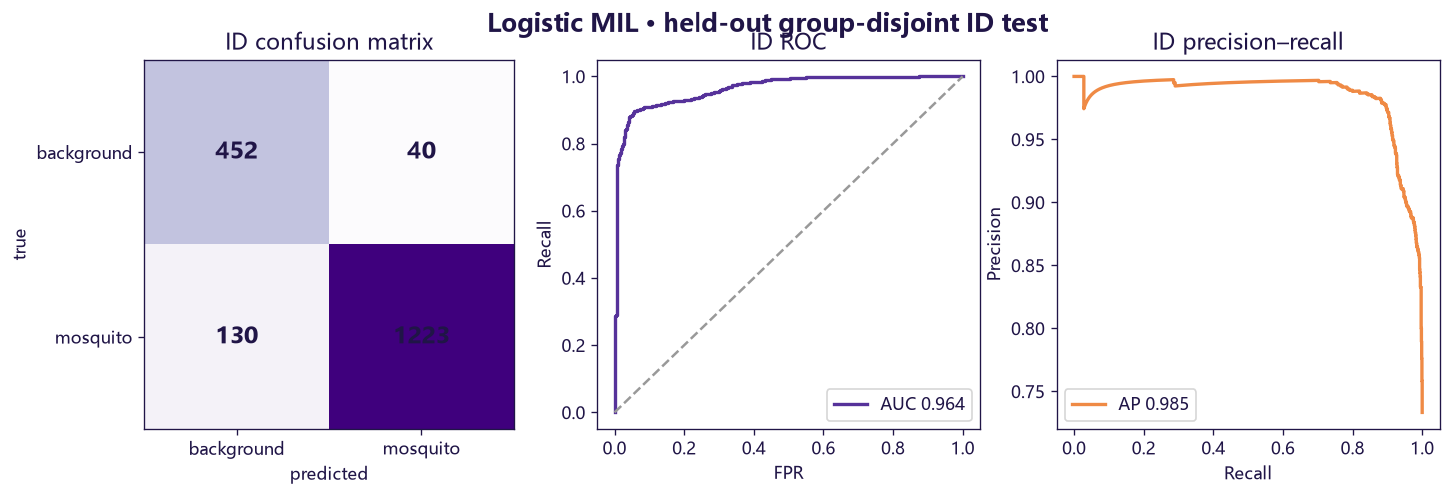

,threshold,accuracy,balanced_accuracy,recall,false_positive_rate,f1,roc_auc,average_precision
0,0.32,0.907859,0.911308,0.903917,0.081301,0.935015,0.963547,0.984683


In [13]:
def binary_metrics(y_true, probabilities, threshold):
    y_true = np.asarray(y_true, dtype=int); probabilities = np.asarray(probabilities, dtype=float)
    pred = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold), "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "recall": recall_score(y_true, pred), "false_positive_rate": fp/(fp+tn),
        "f1": f1_score(y_true, pred), "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }

id_result = binary_metrics(labels[test_indices], frozen_test_prob, threshold)
assert abs(id_result["f1"] - .9350152905198776) < 1e-12
assert abs(id_result["false_positive_rate"] - .08130081300813008) < 1e-12

fpr, tpr, _ = roc_curve(labels[test_indices], frozen_test_prob)
precision, recall, _ = precision_recall_curve(labels[test_indices], frozen_test_prob)
cm = np.array(id_result["confusion_matrix"])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cm, cmap="Purples")
for (i, j), value in np.ndenumerate(cm): axes[0].text(j, i, value, ha="center", va="center", fontsize=14, fontweight="bold")
axes[0].set(xticks=[0,1], yticks=[0,1], xticklabels=["background","mosquito"], yticklabels=["background","mosquito"], xlabel="predicted", ylabel="true", title="ID confusion matrix")
axes[1].plot(fpr, tpr, color=COLORS["purple"], lw=2, label=f"AUC {id_result['roc_auc']:.3f}"); axes[1].plot([0,1],[0,1], "--", color="#999")
axes[1].set(xlabel="FPR", ylabel="Recall", title="ID ROC"); axes[1].legend()
axes[2].plot(recall, precision, color=COLORS["orange"], lw=2, label=f"AP {id_result['average_precision']:.3f}")
axes[2].set(xlabel="Recall", ylabel="Precision", title="ID precision–recall"); axes[2].legend()
fig.suptitle("Logistic MIL · held-out group-disjoint ID test", fontsize=15, fontweight="bold")
save_figure(fig, "fig_06_logistic_mil_id_diagnostics.png")
pd.DataFrame([{k: v for k, v in id_result.items() if k != "confusion_matrix"}])


### 6.2 OOD Audio Inference Pipeline

Define paths for the four OOD ZIP archives and the complete inference function. When `RUN_OOD_INFERENCE` is enabled, the code reads each audio file, extracts the same MFCC representation, applies the five-fold Logistic MIL ensemble, and returns clip probabilities. By default, frozen probabilities are used directly.


In [14]:
OOD_ARCHIVES = {
    "negative_data1": (prefer(ROOT / "data/raw/ood_negative/data1.zip", RUNTIME_DIR / "ood/data1.zip"), 0),
    "negative_data2": (prefer(ROOT / "data/raw/ood_negative/data2.zip", RUNTIME_DIR / "ood/data2.zip"), 0),
    "positive_vasconcelos": (prefer(ROOT / "data/raw/ood_positive/vasconcelos.zip", RUNTIME_DIR / "ood/vasconcelos.zip"), 1),
    "positive_other": (prefer(ROOT / "data/raw/ood_positive/other.zip", RUNTIME_DIR / "ood/other.zip"), 1),
}

def predict_mfcc_with_logistic_ensemble(mfcc):
    fold_predictions = []
    raw_features, *_ = make_window_features(trim_existing_zero_padding(mfcc), False, np.random.default_rng(SEED))
    for fold in range(1, 6):
        ckpt = torch.load(logistic_dir / f"fold_{fold}.pt", map_location="cpu", weights_only=False)
        model = WindowLogisticRegression(78); model.load_state_dict(ckpt["model_state_dict"]); model.eval()
        x = torch.from_numpy((raw_features-ckpt["standardizer_mean"])/ckpt["standardizer_scale"]).float()
        mask = torch.ones(1, len(x), dtype=torch.bool)
        fold_predictions.append(float(aggregate_top_k_probabilities(model(x)[None, :], mask, TOP_K)))
    return float(np.mean(fold_predictions))

def infer_ood_archives():
    rows = []
    for source, (archive, label) in OOD_ARCHIVES.items():
        with zipfile.ZipFile(archive) as zf:
            for member in zf.namelist():
                if Path(member).suffix.lower() != ".wav": continue
                try:
                    y, sr = sf.read(io.BytesIO(zf.read(member)), dtype="float32", always_2d=False)
                    if len(y) == 0: raise ValueError("zero-length")
                    if y.ndim == 2: y = y.mean(axis=1)
                    mfcc = extract_mfcc39(y, sr)
                    rows.append((f"{source}::{member}", source, label, predict_mfcc_with_logistic_ensemble(mfcc)))
                except Exception as exc:
                    warnings.warn(f"skip {member}: {exc}")
    return pd.DataFrame(rows, columns=["sample_id", "source", "label", "probability"])

if RUN_OOD_INFERENCE:
    ood_inference = infer_ood_archives()
    print(f"Recomputed inference for {len(ood_inference)} valid OOD audio files.")
else:
    print("RUN_OOD_INFERENCE=False: using frozen probabilities for the fixed 170+170 sample selected with seed 2026.")


RUN_OOD_INFERENCE=False: using frozen probabilities for the fixed 170+170 sample selected with seed 2026.


### 6.3 ID/OOD Comparison of Candidate Models

Load frozen predictions from five candidate models, recompute ID F1, ID FPR, and OOD metrics using each model's training-OOF threshold, save the comparison table, and plot the OOD recall-FPR trade-off.


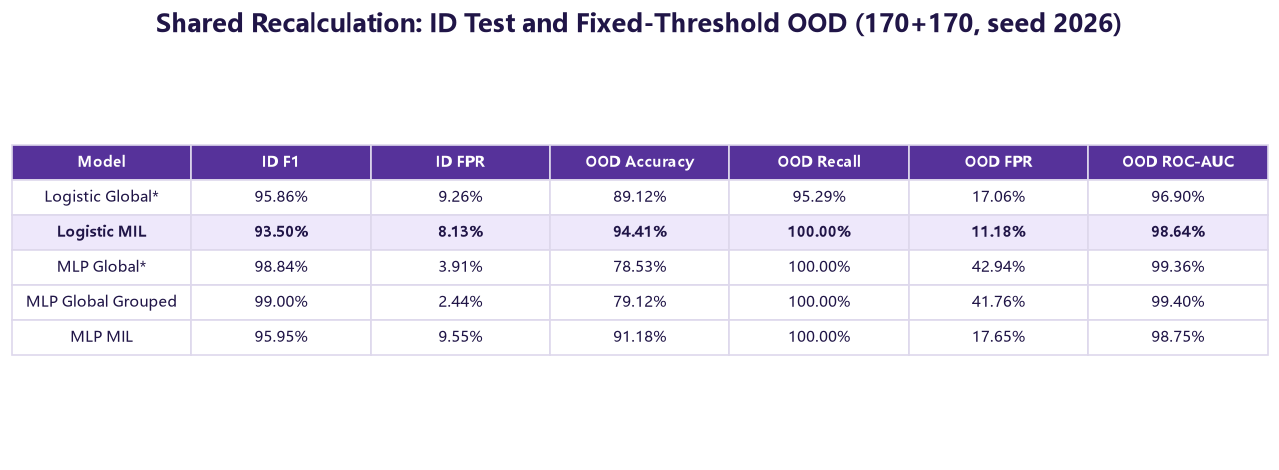

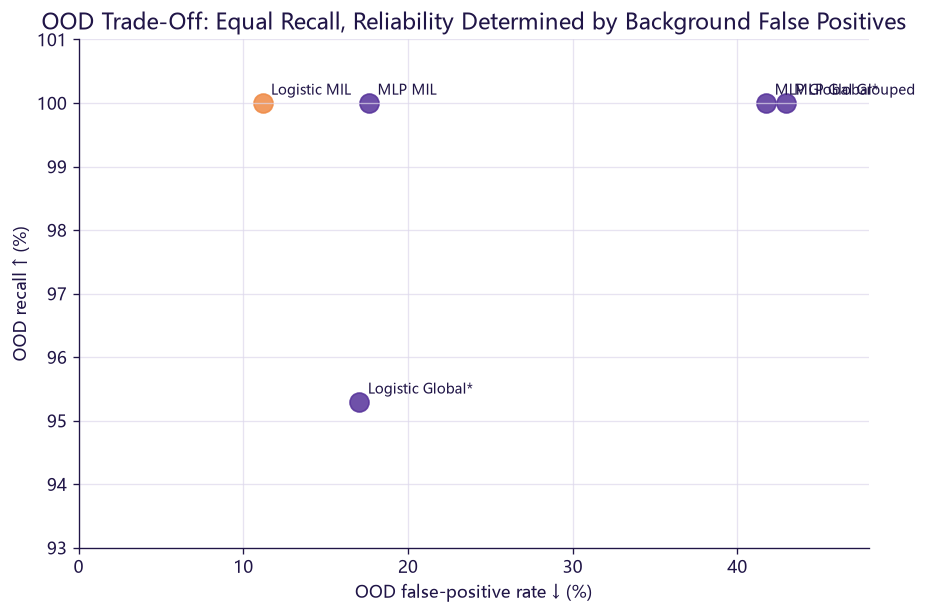

,Model,ID F1,ID FPR,OOD Accuracy,OOD Recall,OOD FPR,OOD ROC-AUC
0,Logistic Global*,95.86%,9.26%,89.12%,95.29%,17.06%,96.90%
1,Logistic MIL,93.50%,8.13%,94.41%,100.00%,11.18%,98.64%
2,MLP Global*,98.84%,3.91%,78.53%,100.00%,42.94%,99.36%
3,MLP Global Grouped,99.00%,2.44%,79.12%,100.00%,41.76%,99.40%
4,MLP MIL,95.95%,9.55%,91.18%,100.00%,17.65%,98.75%


In [15]:
MODEL_DIRS = {
    "Logistic Global*": "logistic_global_gpu", "Logistic MIL": "logistic_mil_gpu",
    "MLP Global*": "mlp_global_gpu", "MLP Global Grouped": "mlp_global_gpu_grouped",
    "MLP MIL": "mlp_mil_gpu",
}
def resolve_model_dir(directory: str) -> Path:
    if directory == "logistic_mil_gpu":
        return logistic_file("metrics.json").parent
    return prefer(ROOT / "outputs" / directory, RUNTIME_DIR / "comparison/id" / directory)
ood_npz = np.load(PATHS["ood_probabilities"])
ood_labels = ood_npz["labels"].astype(int)
comparison_rows = []
recomputed = {}
for display_name, directory in MODEL_DIRS.items():
    model_dir = resolve_model_dir(directory)
    with (model_dir / "metrics.json").open("r", encoding="utf-8") as f: metrics_file = json.load(f)
    model_threshold = float(metrics_file["test_metrics"]["threshold"])
    model_test_indices = np.load(model_dir / "test_indices.npy")
    model_test_prob = np.load(model_dir / "test_probabilities.npy")
    id_metrics = binary_metrics(labels[model_test_indices], model_test_prob, model_threshold)
    ood_metrics = binary_metrics(ood_labels, ood_npz[directory], model_threshold)
    recomputed[display_name] = {"id": id_metrics, "ood": ood_metrics}
    comparison_rows.append({
        "Model": display_name, "ID F1": id_metrics["f1"], "ID FPR": id_metrics["false_positive_rate"],
        "OOD Accuracy": ood_metrics["accuracy"], "OOD Recall": ood_metrics["recall"],
        "OOD FPR": ood_metrics["false_positive_rate"], "OOD ROC-AUC": ood_metrics["roc_auc"],
    })
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(TABLE_DIR / "table_06_model_comparison.csv", index=False, encoding="utf-8-sig")

display_table = comparison.copy()
for column in display_table.columns[1:]: display_table[column] = display_table[column].map(lambda x: f"{100*x:.2f}%")
fig, ax = plt.subplots(figsize=(13.5, 4.5)); ax.axis("off")
table = ax.table(cellText=display_table.values, colLabels=display_table.columns, loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.75)
for (r,c), cell in table.get_celld().items():
    cell.set_edgecolor(COLORS["grid"])
    if r == 0: cell.set_facecolor(COLORS["purple"]); cell.get_text().set_color("white"); cell.get_text().set_fontweight("bold")
    elif display_table.iloc[r-1,0] == "Logistic MIL": cell.set_facecolor("#eee8fb"); cell.get_text().set_fontweight("bold")
ax.set_title("Shared Recalculation: ID Test and Fixed-Threshold OOD (170+170, seed 2026)", fontsize=15, fontweight="bold")
save_figure(fig, "table_06_model_comparison.png")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for row in comparison_rows:
    ax.scatter(row["OOD FPR"]*100, row["OOD Recall"]*100, s=130, color=COLORS["orange"] if row["Model"] == "Logistic MIL" else COLORS["purple"], alpha=.85)
    ax.annotate(row["Model"], (row["OOD FPR"]*100, row["OOD Recall"]*100), xytext=(5,5), textcoords="offset points", fontsize=8.5)
ax.set(xlabel="OOD false-positive rate ↓ (%)", ylabel="OOD recall ↑ (%)", xlim=(0, 48), ylim=(93, 101), title="OOD Trade-Off: Equal Recall, Reliability Determined by Background False Positives")
ax.grid(color=COLORS["grid"], alpha=.7); ax.spines[["top","right"]].set_visible(False)
save_figure(fig, "fig_06_ood_tradeoff.png")
display_table


### 6.4 Shift in OOD Background Probability Distributions

Compare the ID-background and OOD-background probability distributions of MLP Global Grouped and Logistic MIL. Mark each model's fixed OOF threshold to analyze why false-positive rates increase on OOD backgrounds.


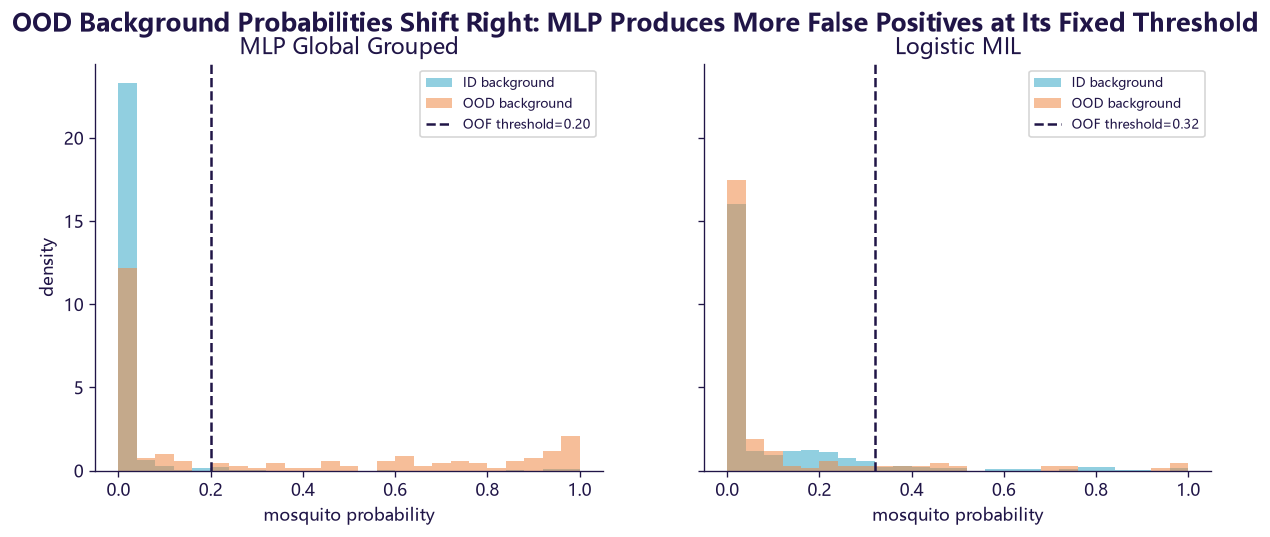

WindowsPath('outputs/notebook_figures/fig_06_mlp_threshold_shift.png')

In [16]:
# Threshold-shift diagnosis: MLP is strong on ID, but OOD background probabilities shift right relative to its fixed ID threshold.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, name in zip(axes, ["MLP Global Grouped", "Logistic MIL"]):
    directory = MODEL_DIRS[name]
    model_dir = resolve_model_dir(directory)
    test_idx = np.load(model_dir / "test_indices.npy"); test_prob = np.load(model_dir / "test_probabilities.npy")
    with (model_dir / "metrics.json").open("r", encoding="utf-8") as f: thr = json.load(f)["test_metrics"]["threshold"]
    id_background = test_prob[labels[test_idx] == 0]
    ood_background = ood_npz[directory][ood_labels == 0]
    bins = np.linspace(0, 1, 26)
    ax.hist(id_background, bins=bins, density=True, alpha=.55, color=COLORS["cyan"], label="ID background")
    ax.hist(ood_background, bins=bins, density=True, alpha=.55, color=COLORS["orange"], label="OOD background")
    ax.axvline(thr, color=COLORS["ink"], linestyle="--", label=f"OOF threshold={thr:.2f}")
    ax.set(xlabel="mosquito probability", title=name); ax.legend(fontsize=8)
    ax.spines[["top","right"]].set_visible(False)
axes[0].set_ylabel("density")
fig.suptitle("OOD Background Probabilities Shift Right: MLP Produces More False Positives at Its Fixed Threshold", fontsize=15, fontweight="bold")
save_figure(fig, "fig_06_mlp_threshold_shift.png")


## 7. Conclusion and Final Model Card

Extract Logistic MIL's ID/OOD metrics, model configuration, and experimental limitations from the shared evaluation results, save the final model card, and generate a summary figure.


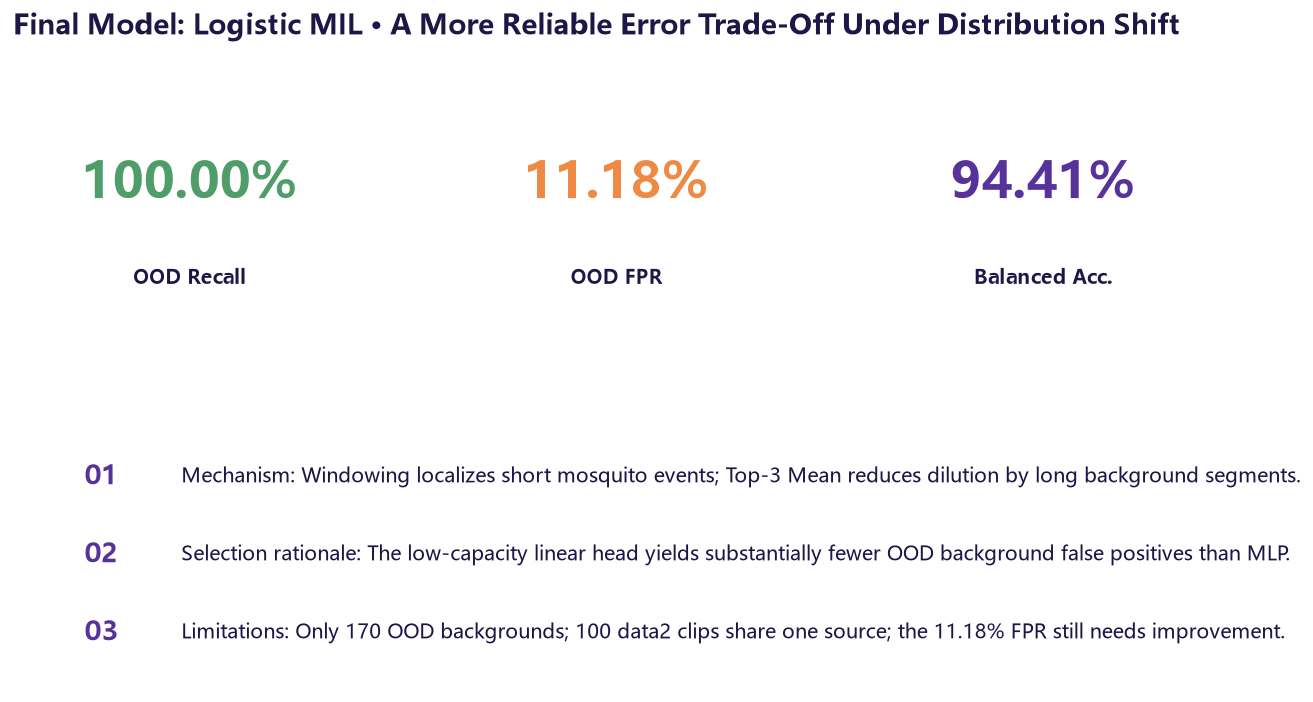

,field,value
0,Input,39-channel MFCC; 64-frame windows; 50% overlap
1,Window classifier,"Linear(78, 1)"
2,Pooling,Top-3 Mean
3,Protocol,20% group test + 5-fold Stratified Group CV
4,Threshold,0.32 (training-pool OOF only)
5,ID F1,93.50%
6,ID FPR,8.13%
7,OOD Recall,100.00%
8,OOD FPR,11.18%
9,OOD Balanced Accuracy,94.41%


In [17]:
final_ood = recomputed["Logistic MIL"]["ood"]
final_card = pd.DataFrame([
    ["Input", "39-channel MFCC; 64-frame windows; 50% overlap"],
    ["Window classifier", "Linear(78, 1)"],
    ["Pooling", "Top-3 Mean"],
    ["Protocol", "20% group test + 5-fold Stratified Group CV"],
    ["Threshold", f"{threshold:.2f} (training-pool OOF only)"],
    ["ID F1", f"{id_result['f1']*100:.2f}%"],
    ["ID FPR", f"{id_result['false_positive_rate']*100:.2f}%"],
    ["OOD Recall", f"{final_ood['recall']*100:.2f}%"],
    ["OOD FPR", f"{final_ood['false_positive_rate']*100:.2f}%"],
    ["OOD Balanced Accuracy", f"{final_ood['balanced_accuracy']*100:.2f}%"],
    ["Limitations", "170 OOD backgrounds; data2 100 clips share one source; FPR remains 11.18%"],
], columns=["field", "value"])
final_card.to_csv(TABLE_DIR / "table_07_final_model_card.csv", index=False, encoding="utf-8-sig")

assert np.isclose(final_ood["recall"], 1.0)
assert np.isclose(final_ood["false_positive_rate"], 19/170)
assert np.isclose(final_ood["balanced_accuracy"], .9441176470588235)

fig = plt.figure(figsize=(13, 6.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1])
values = [("OOD Recall", final_ood["recall"]*100, COLORS["green"]), ("OOD FPR", final_ood["false_positive_rate"]*100, COLORS["orange"]), ("Balanced Acc.", final_ood["balanced_accuracy"]*100, COLORS["purple"])]
for i, (label, value, color) in enumerate(values):
    ax = fig.add_subplot(gs[0, i]); ax.axis("off")
    ax.text(.5, .62, f"{value:.2f}%", ha="center", fontsize=30, fontweight="bold", color=color)
    ax.text(.5, .32, label, ha="center", fontsize=12, fontweight="bold")
ax = fig.add_subplot(gs[1, :]); ax.axis("off")
conclusion = [
    "Mechanism: Windowing localizes short mosquito events; Top-3 Mean reduces dilution by long background segments.",
    "Selection rationale: The low-capacity linear head yields substantially fewer OOD background false positives than MLP.",
    "Limitations: Only 170 OOD backgrounds; 100 data2 clips share one source; the 11.18% FPR still needs improvement.",
]
for i, line in enumerate(conclusion):
    ax.text(.06, .82-i*.30, f"0{i+1}", fontsize=16, fontweight="bold", color=COLORS["purple"], va="center")
    ax.text(.14, .82-i*.30, line, fontsize=12, va="center")
fig.suptitle("Final Model: Logistic MIL · A More Reliable Error Trade-Off Under Distribution Shift", fontsize=17, fontweight="bold")
save_figure(fig, "fig_07_final_model_summary.png")
final_card


## Appendix: Threshold-Recall-FPR Curves

Sweep classification thresholds from 0.01 to 0.99, compute recall/FPR curves for training-pool OOF predictions and the balanced OOD audit set, and verify that all expected figures and tables have been generated.


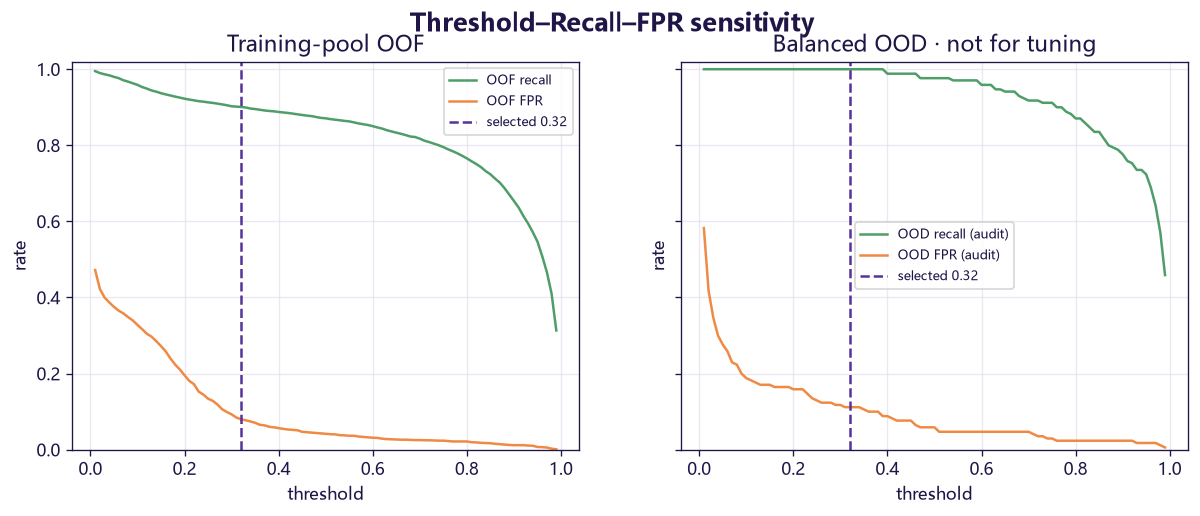

Validation passed: 13 figures and 5 tables.


In [18]:
thresholds = np.arange(.01, 1.00, .01)
oof_recall, oof_fpr, ood_recall, ood_fpr = [], [], [], []
for candidate in thresholds:
    oof_m = binary_metrics(labels[train_indices], frozen_oof, candidate)
    ood_m = binary_metrics(ood_labels, ood_npz["logistic_mil_gpu"], candidate)
    oof_recall.append(oof_m["recall"]); oof_fpr.append(oof_m["false_positive_rate"])
    ood_recall.append(ood_m["recall"]); ood_fpr.append(ood_m["false_positive_rate"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
axes[0].plot(thresholds, oof_recall, label="OOF recall", color=COLORS["green"])
axes[0].plot(thresholds, oof_fpr, label="OOF FPR", color=COLORS["orange"])
axes[1].plot(thresholds, ood_recall, label="OOD recall (audit)", color=COLORS["green"])
axes[1].plot(thresholds, ood_fpr, label="OOD FPR (audit)", color=COLORS["orange"])
for ax, title in zip(axes, ["Training-pool OOF", "Balanced OOD · not for tuning"]):
    ax.axvline(threshold, color=COLORS["purple"], linestyle="--", label=f"selected {threshold:.2f}")
    ax.set(xlabel="threshold", ylabel="rate", ylim=(0, 1.02), title=title); ax.legend(fontsize=8); ax.grid(color=COLORS["grid"], alpha=.6)
fig.suptitle("Threshold–Recall–FPR sensitivity", fontsize=15, fontweight="bold")
save_figure(fig, "appendix_threshold_recall_fpr.png")

expected_figures = {
    "fig_02_dataset_composition.png", "fig_02_mfcc_examples.png",
    "fig_03_short_padding.png", "fig_03_long_windowing.png", "fig_03_top3_pooling.png",
    "fig_04_baseline_evolution.png", "fig_05_model_matrix_and_protocol.png",
    "table_06_model_comparison.png", "fig_06_ood_tradeoff.png", "fig_06_mlp_threshold_shift.png",
    "fig_06_logistic_mil_id_diagnostics.png", "fig_07_final_model_summary.png",
    "appendix_threshold_recall_fpr.png",
}
expected_tables = {
    "table_02_dataset_manifest.csv", "table_04_baseline_evolution.csv",
    "table_05_model_matrix.csv", "table_06_model_comparison.csv",
    "table_07_final_model_card.csv",
}
assert expected_figures <= {p.name for p in FIG_DIR.glob("*")}
assert expected_tables <= {p.name for p in TABLE_DIR.glob("*")}
print(f"Validation passed: {len(expected_figures)} figures and {len(expected_tables)} tables.")
